# 🧠 Workshop NLP Sesi 1: Traditional Machine Learning & AutoML

**Mata Kuliah:** Pemrosesan Bahasa Alami (SD25-32202)  
**Topik:** Klasifikasi Teks dengan *Traditional Machine Learning* menggunakan AutoML (PyCaret)

---

## 🎯 Apa yang Akan Kita Pelajari?

Dalam workshop ini, kita akan membangun sebuah **model klasifikasi teks** yang bisa mendeteksi komentar *toxic* di chat game online Indonesia. Kita akan belajar:

1. **Text Preprocessing** — Bagaimana membersihkan teks yang "kotor" (singkatan, *leetspeak*, slang)
2. **Feature Extraction (TF-IDF)** — Bagaimana komputer "memahami" teks dengan mengubahnya jadi angka
3. **AutoML** — Membandingkan banyak algoritma ML sekaligus tanpa coding manual
4. **Evaluasi Model** — Mengukur seberapa bagus model kita

---

## 📊 Tentang Dataset

Kita menggunakan **Indonesian Chat Dataset** dari Kaggle yang berisi chat dari game *Roblox* dan *Minecraft*.

| Info | Detail |
|------|--------|
| Sumber | Kaggle (jprestiliano) |
| Jumlah Data | ~10.700 chat |
| Bahasa | Indonesia (slang gamer) |
| Tugas | Klasifikasi 4 label |

**4 Label Klasifikasi:**
- 🟢 **Neutral** — Chat biasa, tidak berbahaya
- 🔴 **Violence** — Mengandung unsur kekerasan
- 🟡 **Racist** — Mengandung unsur rasisme
- 🟠 **Harassment** — Mengandung pelecehan

> **Kenapa dataset ini menarik?** Chat gamer sangat "kotor" — penuh singkatan, *leetspeak* (misal `4nj1n9` = `anjing`), dan slang lokal. Ini tantangan nyata dalam NLP!

---
## 📦 Langkah 1: Instalasi & Import

Pertama, kita install semua library yang dibutuhkan. Library utama:
- **`pycaret`** — Framework AutoML yang memudahkan kita membandingkan banyak model sekaligus
- **`kagglehub`** — Untuk mendownload dataset dari Kaggle secara otomatis
- **`pandas`** — Untuk manipulasi data tabel

In [ ]:
# Install dependencies (jalankan sekali saja)
!pip install -q pycaret pandas kagglehub opendatasets matplotlib seaborn

In [1]:
# Import modul-modul yang sudah kita buat
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from config import RAW_CSV, TEXT_COL, LABEL_COL
from download_data import download_dataset
from preprocess import load_and_clean, show_cleaning_examples, clean_text
from train import (
    setup_pycaret,
    compare_all_models,
    tune_best,
    evaluate,
    plot_confusion_matrix,
    plot_feature_importance,
    plot_class_report,
    finalize_and_save,
)

import pandas as pd
pd.set_option('display.max_colwidth', 80)

print("✅ Semua modul berhasil diimport!")

✅ Semua modul berhasil diimport!


---
## 📥 Langkah 2: Download Dataset

Kita akan mendownload dataset secara **otomatis** dari Kaggle. Fungsi ini "pintar" — kalau dataset sudah pernah didownload, dia akan langsung *skip* (tidak download ulang).

> **Bagaimana cara kerjanya?**  
> Kita menggunakan library `kagglehub` yang bisa mengakses dataset publik Kaggle tanpa perlu API key.

In [2]:
# Download dataset dari Kaggle
csv_path = download_dataset()
print(f"\n📁 File tersimpan di: {csv_path}")

✅ Dataset sudah ada: /home/user/Developer/mct-mlp/source/data/indonesian_chat.csv

📁 File tersimpan di: /home/user/Developer/mct-mlp/source/data/indonesian_chat.csv


---
## 🔍 Langkah 3: Eksplorasi Data Awal

Sebelum membangun model, **selalu** lihat datanya dulu! Ini penting untuk memahami:
- Seperti apa bentuk datanya?
- Berapa banyak data per label?
- Apakah datanya *balanced* (seimbang) atau *imbalanced* (tidak seimbang)?

In [3]:
# Baca data mentah
df_raw = pd.read_csv(csv_path)

print(f"📏 Ukuran dataset: {df_raw.shape[0]:,} baris × {df_raw.shape[1]} kolom")
print(f"📋 Kolom: {list(df_raw.columns)}")
print()

# Lihat 5 baris pertama
df_raw.head()

📏 Ukuran dataset: 10,702 baris × 3 kolom
📋 Kolom: ['id', 'chat', 'label']



,id,chat,label
0,1,main mu kek tai cok,violence
1,2,user telat ngasih tau elu edan sarap gue bergaul elu,violence
2,3,kadang berfikir percaya tuhan jatuh berkalikali kadang tuhan ninggalkan oran...,neutral
3,4,user user aku\n\nku tau matamu sipit diliat,racist
4,5,capek deh ketemu kaum cina kapir gini match,racist


📊 Distribusi Label:
   violence    : 2,983 (27.9%)
   neutral     : 2,729 (25.5%)
   racist      : 2,506 (23.4%)
   harassment  : 2,484 (23.2%)
   TOTAL       : 10,702



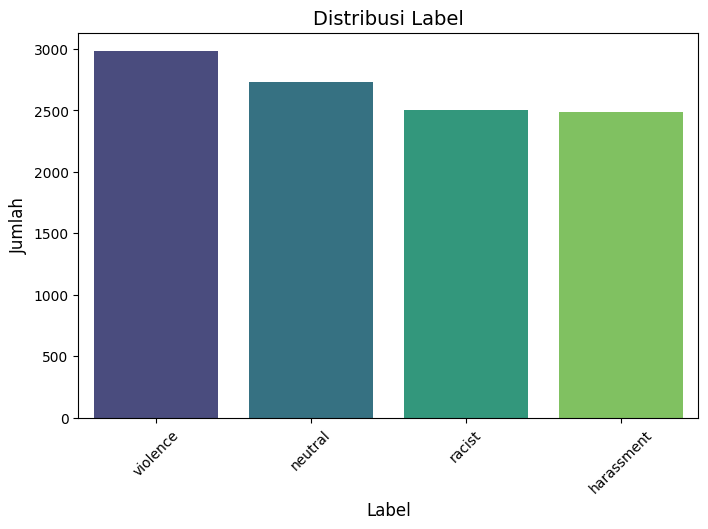

In [4]:
# Distribusi label
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 Distribusi Label:")
print("=" * 30)
label_counts = df_raw[LABEL_COL].value_counts()
for label, count in label_counts.items():
    pct = count / len(df_raw) * 100
    print(f"   {label:12s}: {count:5,} ({pct:.1f}%)")
print(f"   {'TOTAL':12s}: {len(df_raw):5,}\n")

# Visualisasi distribusi label menggunakan bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.title('Distribusi Label', fontsize=14)
plt.xlabel('Label', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
plt.xticks(rotation=45)
plt.show()

---
## 🧹 Langkah 4: Text Preprocessing (Pembersihan Teks)

Ini adalah langkah **paling penting** dalam NLP! Teks mentah dari chat game sangat berantakan. Kita perlu membersihkannya agar model ML bisa "memahami" teks dengan lebih baik.

### Pipeline Pembersihan Kita:

```text
[ TEKS MENTAH ]
       |
       v
( 1. Lowercase )
       |
       v
( 2. Hapus URL )
       |
       v
( 3. Hapus @mention )
       |
       v
( 4. Normalisasi Leetspeak : 4nj1n9 -> anjing )
       |
       v
( 5. Ekspansi Slang        : gblk -> goblok )
       |
       v
( 6. Hapus Simbol )
       |
       v
( 7. Hapus Spasi Berlebih )
       |
       v
[ TEKS BERSIH ]

In [5]:
# Jalankan pipeline pembersihan teks
df = load_and_clean(csv_path)

📂 Membaca dataset: /home/user/Developer/mct-mlp/source/data/indonesian_chat.csv
   Jumlah baris: 10,702
   Kolom: ['id', 'chat', 'label']
🧹 Membersihkan teks...
✅ Selesai! Jumlah baris bersih: 10,702


In [6]:
# Lihat contoh Before vs After pembersihan
print("🔄 Contoh Hasil Pembersihan (Before → After):")
print("=" * 70)
show_cleaning_examples(df, n=10)

🔄 Contoh Hasil Pembersihan (Before → After):


,original,cleaned,label
2882,halah kangkangin sunda ngaceng semenjijikkanya sunda satupun ngalahin pelaya...,halah kangkangin sunda ngaceng semenjijikkanya sunda satupun ngalahin pelaya...,racist
3933,4 agama islam katolik kristen budha desa masjid greja umat katolik greja uma...,agama islam katolik kristen budha desa masjid greja umat katolik greja umat ...,neutral
304,user yg diancam dibunuh presiden republik indonesia ma trus mesti lapor pene...,user yang diancam dibunuh presiden republik indonesia ma terus mesti lapor p...,neutral
3325,kamar guru mushola\n\nnah kristen berdoa aula kristen ga banyak\n\naku temen...,kamar guru musholannnah kristen berdoa aula kristen tidak banyaknnaku temen ...,neutral
2626,memek teryata masi sempit yah dikobel pakai jari masi sakit kontol segede pi...,memek teryata masih sempit yah dikobel pakai jari masih sakit kontol segede ...,harassment
4489,arab taik bisanya ngebacot doang pa diajak mabar ilang,arab taik bisanya ngebacot doang pa diajak mabar ilang,racist
4572,mengikuti bicara jorok kasar jam sgini iktan ah senggama 3 cewek skaligus,mengikuti bicara jorok kasar jam sgini iktan ah senggama cewek skaligus,harassment
6201,character ngetroll game anjing malay,character ngetroll game anjing malay,racist
1413,mahasiswa jurusan â d3 ekonomi keuangan,mahasiswa jurusan de ekonomi keuangan,neutral
3002,user nyimengnya cupu ya kak senior ampuun,user nyimengnya cupu ya kak senior ampuun,violence


In [7]:
# Coba sendiri! Masukkan teks apapun untuk melihat hasilnya
contoh = "t0l0l lu g0blg bgt, noob amat gw k1r4 pro"
print(f"Input : {contoh}")
print(f"Output: {clean_text(contoh)}")

Input : t0l0l lu g0blg bgt, noob amat gw k1r4 pro
Output: tolol lo goblg bgt pemula amat gue kira profesional


---
## ⚙️ Langkah 5: Setup PyCaret (AutoML)

Sekarang kita masuk ke bagian **Machine Learning**!

### Apa itu PyCaret?
PyCaret adalah framework **AutoML** (Automated Machine Learning) yang memungkinkan kita:
- Membandingkan **puluhan model ML** hanya dengan 1 baris kode
- Melakukan **TF-IDF** secara otomatis (mengubah teks → angka)
- **Tuning hyperparameter** dengan mudah

### Apa itu TF-IDF?
**TF-IDF** (*Term Frequency - Inverse Document Frequency*) adalah cara mengubah teks menjadi vektor angka:
- **TF** = Seberapa sering kata muncul di satu dokumen
- **IDF** = Seberapa "unik" kata tersebut di seluruh dataset  
- Kata yang sering muncul di satu dokumen TAPI jarang di dokumen lain → **nilai TF-IDF tinggi** (kata penting!)

```
Contoh: Kata 'anjing' sering muncul di chat toxic, tapi jarang di chat biasa
        → TF-IDF tinggi untuk label Violence/Harassment
        → Model belajar: 'anjing' = indikator toxic!
```

> PyCaret akan otomatis menjalankan TF-IDF karena kita set `text_features=['cleaned_text']`.

In [ ]:
# Setup PyCaret — ini akan melakukan TF-IDF secara otomatis
setup_pycaret(
    data=df,
    use_gpu=True,
    fold=5
    )

⚙️  Menginisialisasi PyCaret...
   Kolom teks  : cleaned_text
   Kolom label : label
   Train size  : 0.8
   Random seed : 42
[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Number of positive: 1, number of negative: 1
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 5070, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] Stopped training because there are n

,Description,Value
0,Session id,42
1,Target,label
2,Target type,Multiclass
3,Target mapping,"harassment: 0, neutral: 1, racist: 2, violence: 3"
4,Original data shape,"(10702, 2)"
5,Transformed data shape,"(10702, 18117)"
6,Transformed train set shape,"(8561, 18117)"
7,Transformed test set shape,"(2141, 18117)"
8,Text features,1
9,Preprocess,True


[LightGBM] [Warning] There are no meaningful features which satisfy the provided configuration. Decreasing Dataset parameters min_data_in_bin or min_data_in_leaf and re-constructing Dataset might resolve this warning.
[LightGBM] [Info] Number of positive: 1, number of negative: 1
[LightGBM] [Info] This is the GPU trainer!!
[LightGBM] [Info] Total Bins 0
[LightGBM] [Info] Number of data points in the train set: 2, number of used features: 0
[LightGBM] [Info] Using GPU Device: NVIDIA GeForce RTX 5070, Vendor: NVIDIA Corporation
[LightGBM] [Info] Compiling OpenCL Kernel with 16 bins...
[LightGBM] [Info] GPU programs have been built
[LightGBM] [Warning] GPU acceleration is disabled because no non-trivial dense features can be found
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] Stopped training because there are no more leaves that mee

---
## 🏟️ Langkah 6: Model Arena — Membandingkan Semua Model!

Ini bagian paling seru! PyCaret akan **melatih dan mengevaluasi banyak model** sekaligus, lalu memberi kita rangking.

### Model yang Akan Dibandingkan (antara lain):
| Model | Tipe | Keterangan |
|-------|------|------------|
| Logistic Regression | Linear | Cepat, bagus untuk baseline |
| Naive Bayes | Probabilistik | Klasik untuk teks |
| SVM | Kernel | Bagus untuk dimensi tinggi (TF-IDF) |
| Random Forest | Ensemble (Tree) | Stabil, jarang overfitting |
| LightGBM | Gradient Boosting | Sangat cepat & akurat |
| XGBoost | Gradient Boosting | Populer di kompetisi |

### Metrik Evaluasi:
- **Accuracy** — Persentase prediksi yang benar
- **F1-Score** — Harmonic mean antara Precision & Recall (lebih adil untuk data *imbalanced*)
- **AUC** — Area Under the ROC Curve

> **⏱️ Proses ini memakan waktu beberapa menit.** Santai, biarkan PyCaret bekerja!

In [ ]:
# Jalankan Model Arena!
best_models = compare_all_models(
    sort="F1",
    include=['lightgbm', 'rf', 'dt', 'svm', 'knn'],
    )

🏟️  Memulai Model Arena (sort by F1)...
   Ini mungkin memakan waktu beberapa menit...



,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
svm,SVM - Linear Kernel,0.8221,0.0000,0.8221,0.8243,0.8223,0.7621,0.7627,5.4400
rf,Random Forest Classifier,0.7917,0.9379,0.7917,0.7999,0.7935,0.7210,0.7226,5.4380
lightgbm,Light Gradient Boosting Machine,0.7650,0.9276,0.7650,0.7714,0.7660,0.6853,0.6867,2.2280
dt,Decision Tree Classifier,0.7093,0.8042,0.7093,0.7142,0.7101,0.6108,0.6119,9.8700
knn,K Neighbors Classifier,0.6760,0.8706,0.6760,0.6812,0.6714,0.5673,0.5708,4.5220



✅ Selesai! Top 5 model telah dipilih.


In [ ]:
# Ambil model #1 (terbaik)
if isinstance(best_models, list):
    best = best_models[0]
    print(f"🏆 Model Terbaik: {best}")
else:
    best = best_models
    print(f"🏆 Model Terbaik: {best}")

---
## 🎯 Langkah 7: Tuning Hyperparameter

Model terbaik dari arena sudah bagus, tapi kita bisa **membuatnya lebih bagus** dengan *tuning hyperparameter*.

### Apa itu Hyperparameter?
Hyperparameter adalah "setting" model yang kita atur **sebelum** training:
- Jumlah pohon di Random Forest
- Learning rate di LightGBM
- Regularization strength di SVM

PyCaret akan mencoba berbagai kombinasi hyperparameter dan memilih yang menghasilkan **F1-Score tertinggi**.

In [ ]:
# Tuning model terbaik
tuned_model = tune_best(best, optimize="F1")

---
## 📊 Langkah 8: Evaluasi Model

Sekarang kita evaluasi model yang sudah di-tune. Kita akan melihat:

### 1. Confusion Matrix
Tabel yang menunjukkan **berapa banyak prediksi yang benar dan salah** untuk setiap label.

```
               Predicted
              N    V    R    H
Actual  N  [950]  10    5    3     ← 950 Neutral benar, 18 salah
        V    20 [180]   8    2     ← 180 Violence benar
        R     5    3 [120]   7     ← dst.
        H    10    5    4 [150]
```

### 2. Feature Importance
Kata-kata apa yang paling **berpengaruh** terhadap prediksi model? Ini memberitahu kita: kata apa yang membuat model menganggap sebuah chat *toxic*?

### 3. Classification Report
Detail **Precision, Recall, dan F1** per label.

In [ ]:
# Confusion Matrix
plot_confusion_matrix(tuned_model)

In [ ]:
# Feature Importance — kata apa yang paling memicu label toxic?
plot_feature_importance(tuned_model)

In [ ]:
# Classification Report
plot_class_report(tuned_model)

---
## 💾 Langkah 9: Finalize & Export Model

Langkah terakhir! Kita akan:
1. **Finalize** — Melatih ulang model pada **seluruh data** (train + test), bukan hanya data train
2. **Export** — Menyimpan model sebagai file `.pkl` yang bisa dipakai nanti

> **Apa itu file `.pkl`?**  
> `.pkl` (pickle) adalah format serialisasi Python. Model yang disimpan dalam format ini bisa di-*load* kembali di kemudian hari untuk melakukan prediksi — **tanpa perlu training ulang**!

In [ ]:
# Finalize dan simpan model
final_model = finalize_and_save(tuned_model)

---
## 🎓 Ringkasan & Poin Penting

### Apa yang Sudah Kita Lakukan:

| Langkah | Apa yang Terjadi | Konsep yang Dipelajari |
|---------|-----------------|----------------------|
| 1. Download | Ambil dataset dari Kaggle | Data acquisition |
| 2. Eksplorasi | Lihat bentuk & distribusi data | EDA (Exploratory Data Analysis) |
| 3. Preprocessing | Bersihkan teks (leetspeak, slang) | Text normalization |
| 4. Setup PyCaret | Ubah teks → angka (TF-IDF) | Feature extraction |
| 5. Model Arena | Bandingkan banyak model sekaligus | AutoML, model selection |
| 6. Tuning | Optimasi hyperparameter | Hyperparameter tuning |
| 7. Evaluasi | Analisis performa model | Confusion matrix, F1-score |
| 8. Export | Simpan model ke `.pkl` | Model deployment |

### Poin Penting:
- **Preprocessing itu kunci!** Model terbaik pun akan buruk jika datanya tidak dibersihkan dengan baik.
- **TF-IDF** mengubah teks menjadi vektor angka berdasarkan frekuensi dan keunikan kata.
- **AutoML** bukan pengganti pemahaman, tapi alat untuk **eksplorasi cepat** model mana yang paling cocok.
- **F1-Score** lebih cocok dari Accuracy untuk data yang *imbalanced*.

---
### 🚀 Langkah Selanjutnya (Sesi 2)
Di sesi berikutnya, kita akan belajar **Deep Learning & Transformer** — pendekatan modern yang jauh lebih canggih untuk NLP!